# Sheet 6: Training a RNN to learn sinusoidal oscillations

In [ ]:
import torch as tc
import torch.nn as nn
import torch.optim as optim
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
# TASK 2: Set the hidden size (dimension of z_t)
# Try different values: start with 2, then 4, 8, 16...
# Find the minimum number that works well
hidden_size = 256 # TODO: Replace with your choice

# Training parameters
epochs = 2000
learning_rate = 1e-4 # TODO: Try different values

# TASK 4: Mini-batching parameters (uncomment and modify when needed)
# seq_length = None     # Length of sampeld subsequences for training
# batch_size = None     # Number of subsequences per batch

Data shape: torch.Size([41, 2])
Observation size: 2
Time steps: 41


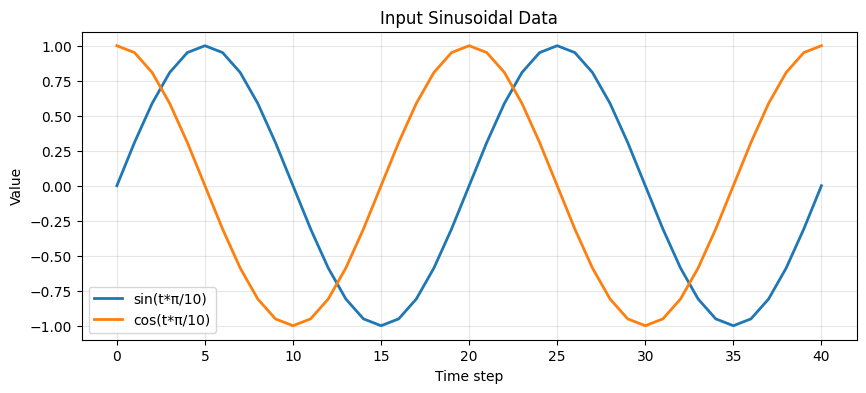

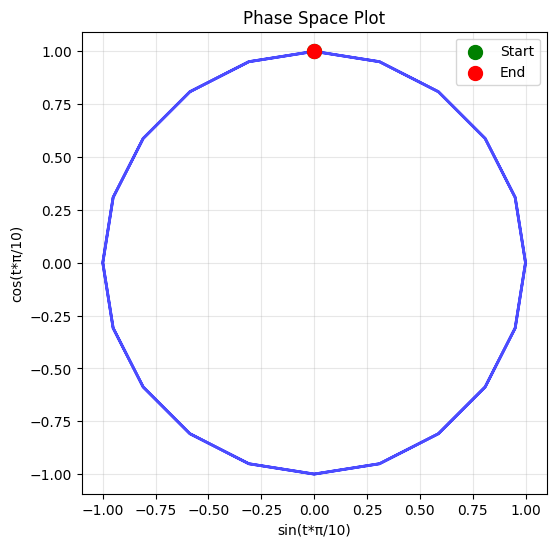

In [ ]:
#%% DATA LOADING AND VISUALIZATION

# Load the sinusoidal data: x_t = [sin(t*π/10), cos(t*π/10)] for t=0,...,40
data = tc.load('sinus.pt')
observation_size = data.shape[1]  # Should be 2 (sin and cos components)

print(f"Data shape: {data.shape}")
print(f"Observation size: {observation_size}")
print(f"Time steps: {data.shape[0]}")

# Plot the input data
plt.figure(figsize=(10, 4))
plt.plot(data[:, 0], label='sin(t*π/10)', linewidth=2)
plt.plot(data[:, 1], label='cos(t*π/10)', linewidth=2)
plt.xlabel('Time step')
plt.ylabel('Value')
plt.title('Input Sinusoidal Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot phase space (sin vs cos)
plt.figure(figsize=(6, 6))
plt.plot(data[:, 0], data[:, 1], 'b-', linewidth=2, alpha=0.7)
plt.scatter(data[0, 0], data[0, 1], c='green', s=100, label='Start', zorder=5)
plt.scatter(data[-1, 0], data[-1, 1], c='red', s=100, label='End', zorder=5)
plt.xlabel('sin(t*π/10)')
plt.ylabel('cos(t*π/10)')
plt.title('Phase Space Plot')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

In [ ]:
#%% MODEL DEFINITION

class LatentRNN(nn.Module):
    """
    Recurrent Neural Network for learning dynamical systems
    
    Architecture:
    z_t = tanh(C * x_{t-1} + W * z_{t-1} + h)  # Hidden state update
    \hat{x}_t = B * z_t + c                    # Output generation
    """
    
    def __init__(self, obs_dim, latent_dim):
        super(LatentRNN, self).__init__()
        
        self.obs_dim = obs_dim        # Dimension of observations (2 for sin/cos)
        self.latent_dim = latent_dim  # Dimension of hidden state z_t
        self.activation = nn.Tanh()
        
        # TASK 2: Implement the RNN layers here

        # Option 1: Use nn.RNN (easier)
        #or 
        # Option 2: Implement manually with nn.Linear layers (more educational)
        # You need to define the following components:
        # 1. Input-to-hidden transformation: U matrix and bias b
        # 2. Hidden-to-hidden transformation: V matrix  
        # 3. Hidden-to-output transformation: W matrix and bias c
        # Hint: You can use nn.Linear layers or define nn.Parameter matrices

        # TODO: Implement the network architecture

        # Input-to-hidden (U * x + b)
        self.input_to_hidden = nn.Linear(obs_dim, latent_dim, bias=True)
        # Hidden-to-hidden (W * z)
        self.hidden_to_hidden = nn.Linear(latent_dim, latent_dim, bias=False)
        # Hidden-to-output (B * z + c)
        self.hidden_to_output = nn.Linear(latent_dim, obs_dim, bias=True)
        
        
    def forward(self, time_series, h0):
        """
        Forward pass through the RNN
        
        Args:
            time_series: Input sequence of shape (seq_len, batch_size, obs_dim)
            h0: Initial hidden state of shape (1, batch_size, latent_dim)
            
        Returns:
            obs_output: Predicted observations of shape (seq_len, batch_size, obs_dim)
            h: Final hidden state of shape (1, batch_size, latent_dim)
        """
        
        # TASK 2: Implement the forward pass
        # The output should be predicted observations and the final hidden state

        # Hint: For each time step, update hidden state and generate output
        
        # TODO: Implement the forward loop
        
        seq_len, batch_size, _ = time_series.shape
        h = h0
        outputs = []

        for t in range(seq_len):
            x_t = time_series[t]  # shape: (batch_size, obs_dim)
            h = self.activation(self.input_to_hidden(x_t) + self.hidden_to_hidden(h))  # z_t
            x_hat = self.hidden_to_output(h)  # \hat{x}_t
            outputs.append(x_hat)

        obs_output = tc.stack(outputs, dim=0)  # (seq_len, batch_size, obs_dim)
        return obs_output, h.unsqueeze(0)  # match shape of (1, batch_size, latent_dim)
    

# Initialize the model
model = LatentRNN(observation_size, hidden_size)
# Print model information
print(f"\nModel Architecture:")
print(f"- Observation dimension: {observation_size}")
print(f"- Hidden dimension: {hidden_size}")
print(f"- Total parameters: {sum(p.numel() for p in model.parameters())}")


Model Architecture:
- Observation dimension: 2
- Hidden dimension: 256
- Total parameters: 66818


In [ ]:
def train(model,learning_rate, moment=0, optimizer_function='SGD', print_loss=True, batch_size=1, batch_sequence_length=1,minibatch=False):
    """
    Training function with configurable optimizers and mini-batching
    
    Students need to implement the missing parts marked with TODO comments.
    """
    
    # TODO: Implement optimizer selection
    # Create the appropriate optimizer based on optimizer_function parameter
    # Available options: 'SGD' (with momentum support) and 'ADAM'
    # Hint: Use optim.SGD() and optim.Adam() from torch.optim
    parameters = list(model.parameters())
    
    if optimizer_function == 'SGD':
        # TODO: Initialize SGD optimizer with learning_rate and momentum
        optimizer = optim.SGD(parameters, lr=learning_rate, momentum=moment)
    elif optimizer_function == 'ADAM':
        # TODO: Initialize Adam optimizer with learning_rate
        optimizer = optim.Adam(parameters, lr=learning_rate)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_function}")
    
    # TODO: Define the loss function
    # Use Mean Squared Error (MSE) loss for this regression task
    loss_function = nn.MSELoss()
    
    losses = []
    if print_loss:
        print(f"\nStarting training for {epochs} epochs...")
        print(f"Optimizer: {optimizer_function}, LR: {learning_rate}, Batch size: {batch_size}, Sequence length: {batch_sequence_length}")
    
    for epoch in range(epochs):
        # TODO: Initialize hidden state for the batch
        # Create a tensor of shape (1, batch_size, hidden_size) with random values
        if minibatch:
            h0 = tc.rand(1, batch_size, hidden_size)
            h = h0
        else:
            h0 = tc.rand(1, 1, hidden_size)
            h = h0
        
        # Prepare full sequences (input and target)
        x = data[:-1]  # Input: all timesteps except the last
        y = data[1:]   # Target: all timesteps except the first
        
        # TODO: Create batch tensors for mini-batching
        # Initialize tensors to hold batch data of shape (batch_sequence_length, batch_size, observation_dim):
        X = tc.zeros(batch_sequence_length, batch_size, observation_size)
        Y = tc.zeros(batch_sequence_length, batch_size, observation_size)
        
        # TODO: Implement mini-batching
        # For each element in the batch, sample a random subsequence from the data
        # The subsequence should start at a random index and have length batch_sequence_length
        # Make sure the random index doesn't exceed the data bounds
        if minibatch:
            for j in range(batch_size):
                # TODO: Sample a random starting index for the subsequence
                # Ensure: 0 <= ind <= len(x) - batch_sequence_length
                ind = tc.randint(0, len(x) - batch_sequence_length + 1, (1,)).item()
                end_ind = ind+batch_sequence_length
                # TODO: Extract subsequence and assign to batch tensors
                X[:,j,:] = x[ind:end_ind]
                Y[:,j,:] = y[ind:end_ind]
        
        # TODO: Forward pass
        # 1. Zero the gradients from previous iteration
        # 2. Run the model forward pass with input X and initial hidden state h0
        # 3. Calculate the loss between model output and target Y
        optimizer.zero_grad()

        if minibatch:
            obs_output, h = model(X,h)
            epoch_loss = loss_function(obs_output,Y)
        else:
            #print(x.unsqueeze(1).shape)
            obs_output, h = model(x.unsqueeze(1),h)
            #print(obs_output.shape)
            epoch_loss = loss_function(obs_output,y)

        
        
        # TODO: Backward pass and optimization step
        # 1. Compute gradients via backpropagation
        # 2. Update model parameters
        epoch_loss.backward()

        optimizer.step()
        
        # Store loss for plotting
        losses.append(epoch_loss.item())
        
        # Print progress
        if epoch % 10 == 0 and print_loss:
            print(f"Epoch: {epoch} loss {epoch_loss.item():.6f}")
    
    return losses

In [ ]:
import matplotlib.pyplot as plt

def plot_results(arrays, hyperparams_list, nrows=1, ncols=None, log_y=False):
    """
    Plots each array in `arrays` as a subplot using the specified grid layout,
    with titles showing the corresponding hyperparameters.

    Parameters:
    - arrays: list of 1D numpy arrays or torch tensors representing y-values
    - hyperparams_list: list of dicts with keys:
        'learning_rate', 'moment', 'optimizer_function',
        'batch_size', 'batch_sequence_length', 'minibatch'
    - nrows: number of rows in the subplot grid
    - ncols: number of columns in the subplot grid (calculated automatically if None)
    - log_y: bool, if True sets y-axis to logarithmic scale
    """
    n = len(arrays)
    assert len(hyperparams_list) == n, "Each array must have a matching set of hyperparameters."

    if ncols is None:
        ncols = (n + nrows - 1) // nrows  # Auto-fit columns to rows

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows), squeeze=False)

    for idx, (y_vals, hyperparams) in enumerate(zip(arrays, hyperparams_list)):
        row = idx // ncols
        col = idx % ncols
        ax = axes[row][col]

        x_vals = range(len(y_vals))
        ax.plot(x_vals, y_vals)

        if log_y:
            ax.set_yscale('log')

        if hyperparams['minibatch']:
            title = (
                f"LR: {hyperparams['learning_rate']}, "
                f"Momentum: {hyperparams['moment']}, "
                f"Opt: {hyperparams['optimizer_function']}, "
                f"Batch: {hyperparams['batch_size']}, \n"
                f"SeqLen: {hyperparams['batch_sequence_length']},"
                f"Minibatch: {hyperparams['minibatch']}"
            )
        else: 
            title = (
                f"LR: {hyperparams['learning_rate']}, "
                f"Momentum: {hyperparams['moment']}, "
                f"Opt: {hyperparams['optimizer_function']}, \n"
                f"SeqLen: {hyperparams['batch_sequence_length']},"
                f"Minibatch: {hyperparams['minibatch']}"
            )
        ax.set_title(title)
        ax.set_ylabel("Value")
        ax.grid(True)

    # Hide any unused subplots
    for idx in range(n, nrows * ncols):
        fig.delaxes(axes[idx // ncols][idx % ncols])

    for ax in axes[-1]:
        ax.set_xlabel("Step")

    plt.tight_layout()
    plt.show()


In [ ]:
# Train the models
optimisers = ['SGD','ADAM']
minibatch = [False,True]
LR = [1e-4,1e-3,1e-2]
moments=[0,0.5,0.9]

hyperparam_list = []
losses_list = []

min_loss = 10000


for opt in optimisers: 
    for b in minibatch:
        for lr in LR:
            for i in moments:
                model = LatentRNN(observation_size, hidden_size)
                hparams = {'learning_rate':lr, 'moment':i, 'optimizer_function':opt, 'batch_size':5, 'batch_sequence_length':15, 'minibatch':b}
                losses = train(model,lr, moment=i, optimizer_function=opt, 
                    print_loss=False, batch_size=5, batch_sequence_length=10,minibatch=b) # TODO: input the right hyperparameters
                if losses[-1] < min_loss:
                    min_loss = losses[-1]
                    print(min_loss)
                    hparams_ll = hparams # least loss hyper params
                losses_list.append(losses)
                hyperparam_list.append(hparams)



0.5018653273582458


{'learning_rate': 0.01, 'moment': 0.5, 'optimizer_function': 'ADAM', 'batch_size': 5, 'batch_sequence_length': 15, 'minibatch': True}
36


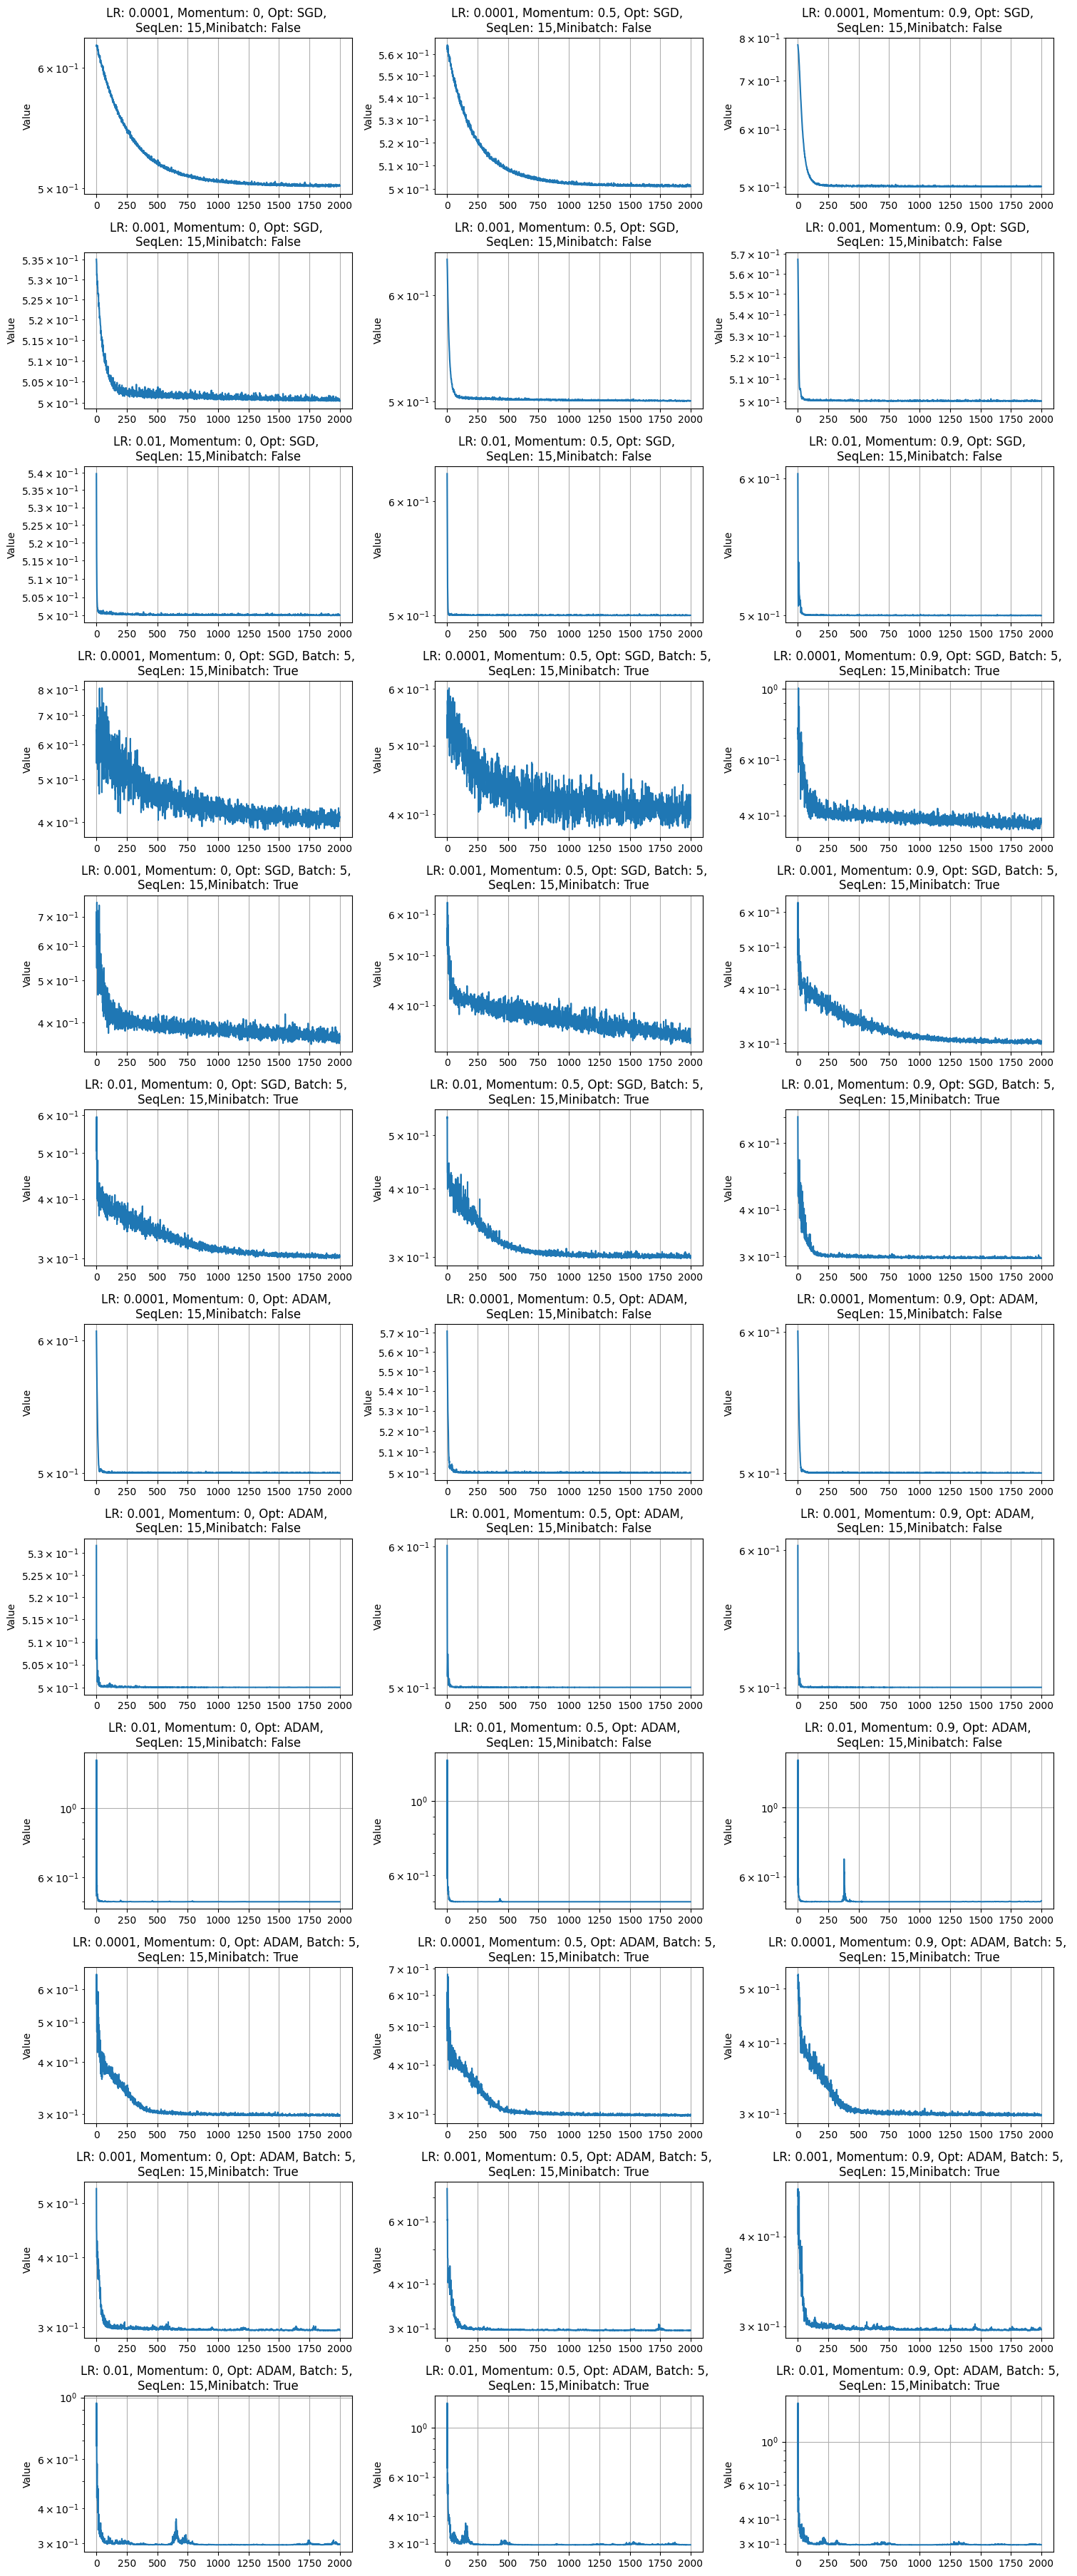

In [ ]:
print(hparams_ll)

num_plots = len(optimisers)*len(minibatch)*len(LR)*len(moments)
print(num_plots)

plot_results(losses_list, hyperparam_list,nrows=13,ncols=3,log_y=True)

In [ ]:
model = LatentRNN(observation_size, hidden_size)

losses = train(model,**hparams_ll)


Starting training for 2000 epochs...
Optimizer: ADAM, LR: 0.01, Batch size: 5, Sequence length: 15
Epoch: 0 loss 0.763071
Epoch: 10 loss 0.615447
Epoch: 20 loss 0.477574
Epoch: 30 loss 0.483992
Epoch: 40 loss 0.495662
Epoch: 50 loss 0.470244
Epoch: 60 loss 0.467003
Epoch: 70 loss 0.469406
Epoch: 80 loss 0.467054
Epoch: 90 loss 0.457128
Epoch: 100 loss 0.457372
Epoch: 110 loss 0.456145
Epoch: 120 loss 0.455245
Epoch: 130 loss 0.455455
Epoch: 140 loss 0.455827
Epoch: 150 loss 0.455840
Epoch: 160 loss 0.454981
Epoch: 170 loss 0.454985
Epoch: 180 loss 0.454858
Epoch: 190 loss 0.455064
Epoch: 200 loss 0.454996
Epoch: 210 loss 0.455103
Epoch: 220 loss 0.455008
Epoch: 230 loss 0.455058
Epoch: 240 loss 0.456058
Epoch: 250 loss 0.455060
Epoch: 260 loss 0.455726
Epoch: 270 loss 0.455990
Epoch: 280 loss 0.455178
Epoch: 290 loss 0.455057
Epoch: 300 loss 0.455169
Epoch: 310 loss 0.455926
Epoch: 320 loss 0.455328
Epoch: 330 loss 0.455060
Epoch: 340 loss 0.455044
Epoch: 350 loss 0.454853
Epoch: 360 

In [ ]:
#%% MODEL EVALUATION AND PREDICTION

# Generate predictions for 5 times the original sequence length
prediction_length = 5 * data.shape[0]

with tc.no_grad():
    # Initialize hidden state and predictions tensor
    h0 = tc.rand(1, 1, hidden_size)
    out, h = model(data.unsqueeze(1),h0)
    #h = h0
    predictions = tc.zeros(prediction_length,1,observation_size)
    
    # Start with first data point
    input_ = data[0:1].unsqueeze(1)  # Shape: (1, 1, obs_dim)
    out, h = model(input_,h)
    predictions[0] = out
    
    # Generate sequence autoregressively, i.e. freely by providing the output as input
    for i in range(1,prediction_length):
        # TODO: make predictions and use prediction as input
        out, h = model(input_,h)
        predictions[i] = out
        

Data shape: torch.Size([205, 2])
Time steps: 205


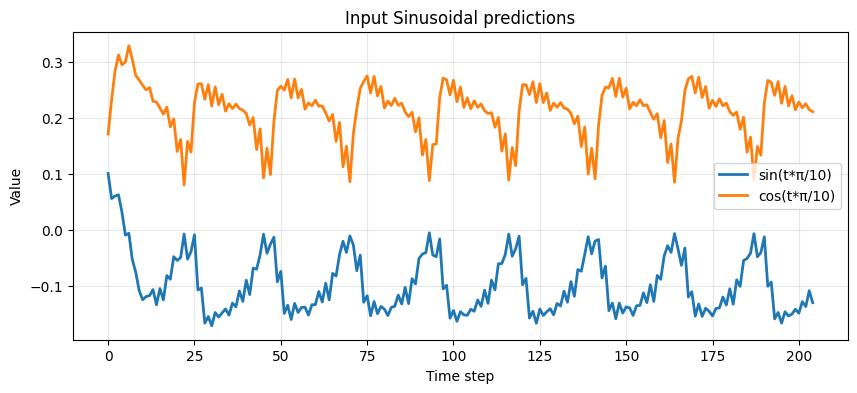

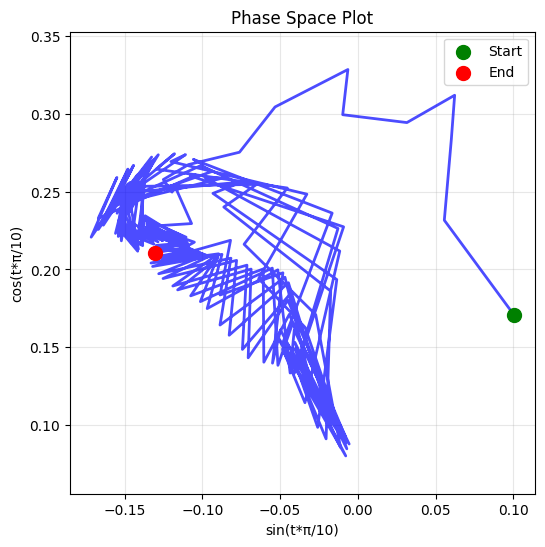

In [ ]:
#%% VISUALIZATION OF RESULTS
predictions = predictions.squeeze()
print(f"Data shape: {predictions.shape}")
print(f"Time steps: {predictions.shape[0]}")

# Plot the input data
plt.figure(figsize=(10, 4))
plt.plot(predictions[:, 0], label='sin(t*π/10)', linewidth=2)
plt.plot(predictions[:, 1], label='cos(t*π/10)', linewidth=2)
plt.xlabel('Time step')
plt.ylabel('Value')
plt.title('Input Sinusoidal predictions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot phase space (sin vs cos)
plt.figure(figsize=(6, 6))
plt.plot(predictions[:, 0], predictions[:, 1], 'b-', linewidth=2, alpha=0.7)
plt.scatter(predictions[0, 0], predictions[0, 1], c='green', s=100, label='Start', zorder=5)
plt.scatter(predictions[-1, 0], predictions[-1, 1], c='red', s=100, label='End', zorder=5)
plt.xlabel('sin(t*π/10)')
plt.ylabel('cos(t*π/10)')
plt.title('Phase Space Plot')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()